# Context-Conditioned Diffusion

## Step 0: Local Debug Setup

This notebook adapts the plan for local CPU debugging instead of Colab. It avoids Google Drive and clone cells, uses repo-local output folders, and keeps the code device-agnostic.

In [23]:
import itertools
import json
import math
import os
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm.auto import tqdm

try:
    from torchinfo import summary
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torchinfo'])
    from torchinfo import summary

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.data_load import DataModule
from utils.losses import masked_mae, masked_rmse, full_mae, full_rmse, psnr, masked_l1_loss

print(f'project_root: {project_root}')
print(f'python: {sys.executable}')
print(f'torch: {torch.__version__}')


project_root: C:\Local\LSE studies\st456-project-wt2026-transformers
python: c:\Users\user\AppData\Local\Programs\Python\Python313\python.exe
torch: 2.11.0+cpu


In [24]:
# create output directories, checkpoints and history will be saved here
# change this if you want to save to a different location

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    root_dir = Path('/content/drive/MyDrive/ST456_Final_Project/context_diffusion')
else:
    root_dir = project_root / 'artifacts' / 'context_diffusion'

checkpoint_dir = root_dir / 'checkpoints'
vae_checkpoint_dir = checkpoint_dir / 'vae'
diffusion_checkpoint_dir = checkpoint_dir / 'diffusion'
history_dir = root_dir / 'history'

for path in [root_dir, checkpoint_dir, vae_checkpoint_dir, diffusion_checkpoint_dir, history_dir]:
    path.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
print(f'cuda available: {torch.cuda.is_available()}')
print('output directories:')
for path in [root_dir, vae_checkpoint_dir, diffusion_checkpoint_dir, history_dir]:
    print(f'  - {path}')


device: cpu
cuda available: False
output directories:
  - C:\Local\LSE studies\st456-project-wt2026-transformers\artifacts\context_diffusion
  - C:\Local\LSE studies\st456-project-wt2026-transformers\artifacts\context_diffusion\checkpoints\vae
  - C:\Local\LSE studies\st456-project-wt2026-transformers\artifacts\context_diffusion\checkpoints\diffusion
  - C:\Local\LSE studies\st456-project-wt2026-transformers\artifacts\context_diffusion\history


## Step 1: Data Loading

The plan used a full local dataset setup. For local debugging, this uses the tiny streamed configuration requested by the project note: `batch_size=2`, `max_train_samples=16`, `max_val_samples=8`, `max_test_samples=8`, CPU-safe, and `num_workers=0`.

In [25]:
dm = DataModule(
    repo_id='han2o/grant-ortsaem-processedV3',
    variant='long_gaps',
    input_key='masked_spectrogram',
    target_key='spectrogram',
    mask_key='mask',
    batch_size=2,
    streaming=True,
    max_train_samples=16,
    max_val_samples=8,
    max_test_samples=8,
    num_workers=0,
)

train_loader, val_loader, test_loader = dm.get_dataloaders()
print('Built dataloaders successfully.')
print(f'  train_loader: {type(train_loader).__name__}')
print(f'  val_loader:   {type(val_loader).__name__}')
print(f'  test_loader:  {type(test_loader).__name__}')
print(f'  batch_size:   {dm.batch_size}')
print(f'  streaming:    {dm.streaming}')
print(f'  max samples:  train={dm.max_train_samples}, val={dm.max_val_samples}, test={dm.max_test_samples}')


Resolving data files:   0%|          | 0/500 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Built dataloaders successfully.
  train_loader: DataLoader
  val_loader:   DataLoader
  test_loader:  DataLoader
  batch_size:   2
  streaming:    True
  max samples:  train=16, val=8, test=8


Batch keys: ['x', 'y', 'mask', 'example_id', 'split', 'recording_idx', 'clip_idx', 'audio_filename', 'sample_rate', 'clip_duration_seconds', 'n_mels', 'time_frames', 'hop_length', 'gap_seconds', 'gap_frames', 'mask_start_frame', 'mask_end_frame']
x shape:    (2, 1, 128, 1876), dtype=torch.float32, device=cpu, min=0.0000, max=9.2416
y shape:    (2, 1, 128, 1876), dtype=torch.float32, device=cpu, min=0.0000, max=9.2416
mask shape: (2, 1, 128, 1876), dtype=torch.float32, unique=tensor([0., 1.])
gap_seconds: tensor([2.3601, 4.2196], dtype=torch.float64)
Estimated gap columns for sample 0: start=537, end=685, width=148


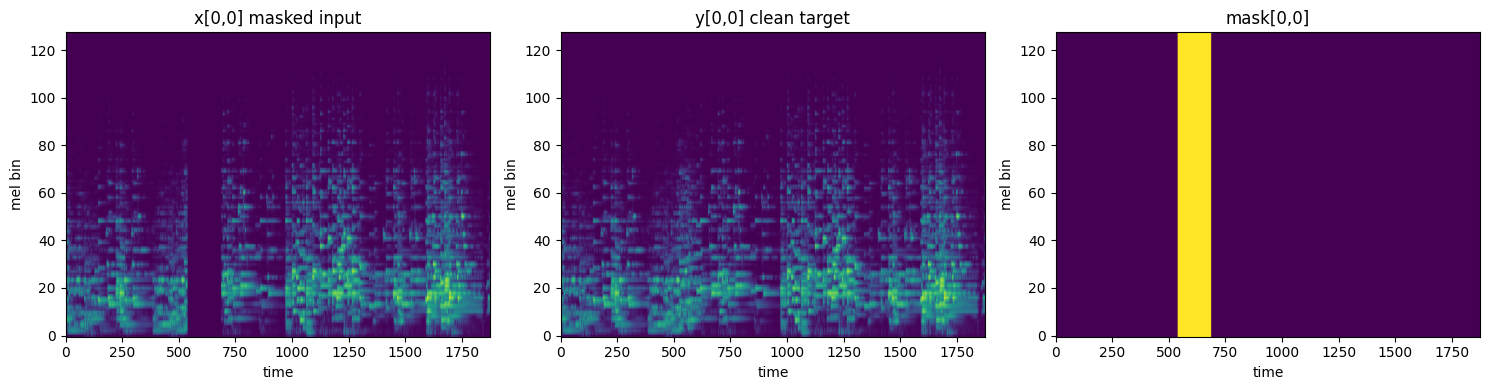

In [26]:
batch = next(iter(train_loader))
x = batch['x']
y = batch['y']
mask = batch['mask']

print('Batch keys:', list(batch.keys()))
print(f'x shape:    {tuple(x.shape)}, dtype={x.dtype}, device={x.device}, min={x.min().item():.4f}, max={x.max().item():.4f}')
print(f'y shape:    {tuple(y.shape)}, dtype={y.dtype}, device={y.device}, min={y.min().item():.4f}, max={y.max().item():.4f}')
print(f'mask shape: {tuple(mask.shape)}, dtype={mask.dtype}, unique={torch.unique(mask)}')

if 'gap_seconds' in batch:
    print('gap_seconds:', batch['gap_seconds'])

mask_cols = (mask[0, 0] > 0.5).any(dim=0)
masked_idx = torch.where(mask_cols)[0]
if len(masked_idx) > 0:
    gap_start = int(masked_idx[0].item())
    gap_end = int(masked_idx[-1].item()) + 1
    print(f'Estimated gap columns for sample 0: start={gap_start}, end={gap_end}, width={gap_end - gap_start}')
else:
    print('No masked columns detected in sample 0.')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(x[0, 0].cpu(), origin='lower', aspect='auto')
axes[0].set_title('x[0,0] masked input')
axes[1].imshow(y[0, 0].cpu(), origin='lower', aspect='auto')
axes[1].set_title('y[0,0] clean target')
axes[2].imshow(mask[0, 0].cpu(), origin='lower', aspect='auto')
axes[2].set_title('mask[0,0]')
for ax in axes:
    ax.set_xlabel('time')
    ax.set_ylabel('mel bin')
plt.tight_layout()
plt.show()


## Step 2: Context Splitting Utility

This separates each sample into left-context and right-context tensors, padded back to the original width so they remain convolution-friendly.

In [27]:
def split_context(z: torch.Tensor, mask_latent: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """Split a masked tensor into left-context and right-context views, padded back to full width."""
    if z.ndim != 4:
        raise ValueError(f'z must have shape (B, C, H, W), got {tuple(z.shape)}')
    if mask_latent.ndim != 4:
        raise ValueError(f'mask_latent must have shape (B, 1, H, W), got {tuple(mask_latent.shape)}')
    if z.shape[0] != mask_latent.shape[0] or z.shape[-2:] != mask_latent.shape[-2:]:
        raise ValueError(
            f'z and mask_latent must agree on batch/space dims, got z={tuple(z.shape)}, mask={tuple(mask_latent.shape)}'
        )

    z_left = torch.zeros_like(z)
    z_right = torch.zeros_like(z)

    for b in range(z.shape[0]):
        mask_cols = (mask_latent[b, 0] > 0.5).any(dim=0)
        masked_idx = torch.where(mask_cols)[0]

        if masked_idx.numel() == 0:
            # No gap detected: keep the full tensor in both views for easier debugging.
            z_left[b] = z[b]
            z_right[b] = z[b]
            continue

        gap_start = int(masked_idx[0].item())
        gap_end = int(masked_idx[-1].item()) + 1

        if gap_start > 0:
            z_left[b, :, :, :gap_start] = z[b, :, :, :gap_start]
        if gap_end < z.shape[-1]:
            z_right[b, :, :, gap_end:] = z[b, :, :, gap_end:]

    return z_left, z_right


In [28]:
def nonzero_col_range(tensor_4d: torch.Tensor, sample_idx: int) -> tuple[int | None, int | None]:
    cols = (tensor_4d[sample_idx].abs().sum(dim=(0, 1)) > 0)
    idx = torch.where(cols)[0]
    if idx.numel() == 0:
        return None, None
    return int(idx[0].item()), int(idx[-1].item()) + 1

z_test = torch.ones(2, 1, 4, 10)
mask_test = torch.zeros(2, 1, 4, 10)
mask_test[0, :, :, 3:6] = 1
mask_test[1, :, :, 6:8] = 1

z_left_test, z_right_test = split_context(z_test, mask_test)

print('split_context smoke test')
print('  z_test shape:', tuple(z_test.shape))
print('  z_left shape:', tuple(z_left_test.shape))
print('  z_right shape:', tuple(z_right_test.shape))
for sample_idx in range(z_test.shape[0]):
    mask_cols = torch.where((mask_test[sample_idx, 0] > 0.5).any(dim=0))[0]
    gap_start = int(mask_cols[0].item())
    gap_end = int(mask_cols[-1].item()) + 1
    left_range = nonzero_col_range(z_left_test, sample_idx)
    right_range = nonzero_col_range(z_right_test, sample_idx)
    print(f'  sample {sample_idx}: gap=[{gap_start}, {gap_end}), left_nonzero={left_range}, right_nonzero={right_range}')


split_context smoke test
  z_test shape: (2, 1, 4, 10)
  z_left shape: (2, 1, 4, 10)
  z_right shape: (2, 1, 4, 10)
  sample 0: gap=[3, 6), left_nonzero=(0, 3), right_nonzero=(6, 10)
  sample 1: gap=[6, 8), left_nonzero=(0, 6), right_nonzero=(8, 10)


## Step 3: Context Encoder Module

The default module below matches the plan for latent-space context (`in_channels=4`). A second debug instantiation at the end uses `in_channels=1`, because later local VAE debugging will encode spectrogram-space context directly.

In [29]:
def _group_norm(num_channels: int, requested_groups: int = 8) -> nn.GroupNorm:
    groups = min(requested_groups, num_channels)
    while num_channels % groups != 0 and groups > 1:
        groups -= 1
    return nn.GroupNorm(groups, num_channels)


class ContextEncoder(nn.Module):
    def __init__(self, in_channels: int = 4, base_channels: int = 64, context_dim: int = 256):
        super().__init__()
        self.conv_in = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.block1 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels, kernel_size=3, padding=1),
            _group_norm(base_channels),
            nn.SiLU(),
        )
        self.down1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.block2 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, kernel_size=3, padding=1),
            _group_norm(base_channels * 2),
            nn.SiLU(),
        )
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)
        self.block3 = nn.Sequential(
            nn.Conv2d(base_channels * 4, base_channels * 4, kernel_size=3, padding=1),
            _group_norm(base_channels * 4),
            nn.SiLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.proj = nn.Sequential(
            nn.Linear(base_channels * 4, context_dim),
            nn.SiLU(),
            nn.Linear(context_dim, context_dim),
        )
        self.act = nn.SiLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.act(self.conv_in(x))
        x = self.block1(x)
        x = self.act(self.down1(x))
        x = self.block2(x)
        x = self.act(self.down2(x))
        x = self.block3(x)
        x = self.pool(x).flatten(1)
        return self.proj(x)


In [30]:
ctx_encoder_latent = ContextEncoder(in_channels=4, base_channels=64, context_dim=256).to(device)
summary(ctx_encoder_latent, input_size=(2, 4, 16, 64), device=str(device))

ctx_encoder_spec = ContextEncoder(in_channels=1, base_channels=32, context_dim=128).to(device)
x_small = x[:2].to(device)
with torch.no_grad():
    cond_small = ctx_encoder_spec(x_small)

print('\nContextEncoder debug forward pass')
print(f'  input shape:  {tuple(x_small.shape)} on {x_small.device}')
print(f'  output shape: {tuple(cond_small.shape)}')
print(f'  output mean:  {cond_small.mean().item():.6f}')
print(f'  output std:   {cond_small.std().item():.6f}')



ContextEncoder debug forward pass
  input shape:  (2, 1, 128, 1876) on cpu
  output shape: (2, 128)
  output mean:  -0.006566
  output std:   0.061266


## Step 4: Context-Aware VAE Architecture

This keeps the same residual/downsample/upsample style as `diffusion.ipynb`, but adds FiLM conditioning from the context embedding. For local robustness, the decoder can resize back to the exact gap shape when the gap width is not divisible by `2^3`.

In [31]:
class ResBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, groups: int = 8):
        super().__init__()
        self.norm1 = _group_norm(in_channels, groups)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = _group_norm(out_channels, groups)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)
        h = self.conv1(self.act1(self.norm1(x)))
        h = self.conv2(self.act2(self.norm2(h)))
        return h + residual


class DownSample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class UpSample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, target_size: tuple[int, int] | None = None) -> torch.Tensor:
        if target_size is None:
            x = F.interpolate(x, scale_factor=2, mode='nearest')
        else:
            x = F.interpolate(x, size=target_size, mode='nearest')
        return self.conv(x)


class FiLMLayer(nn.Module):
    def __init__(self, num_channels: int, cond_dim: int):
        super().__init__()
        self.scale_proj = nn.Linear(cond_dim, num_channels)
        self.shift_proj = nn.Linear(cond_dim, num_channels)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        scale = self.scale_proj(cond)[:, :, None, None]
        shift = self.shift_proj(cond)[:, :, None, None]
        return x * (1.0 + scale) + shift


class DualFiLMLayer(nn.Module):
    """
    FiLM conditioning that keeps left and right context separate.
    Each residual block learns its own blend of left/right influence via
    a learned gate. The gate is applied element-wise per channel.
    """
    def __init__(self, num_channels: int, cond_dim: int):
        super().__init__()
        self.scale_left = nn.Linear(cond_dim, num_channels)
        self.shift_left = nn.Linear(cond_dim, num_channels)
        self.scale_right = nn.Linear(cond_dim, num_channels)
        self.shift_right = nn.Linear(cond_dim, num_channels)
        self.gate = nn.Linear(2 * cond_dim, num_channels)

    def forward(
        self,
        x: torch.Tensor,
        c_left: torch.Tensor,
        c_right: torch.Tensor,
    ) -> torch.Tensor:
        # x: (B, C, H, W)   c_left, c_right: (B, cond_dim)
        s_l = self.scale_left(c_left)[:, :, None, None]
        b_l = self.shift_left(c_left)[:, :, None, None]
        s_r = self.scale_right(c_right)[:, :, None, None]
        b_r = self.shift_right(c_right)[:, :, None, None]
        g = torch.sigmoid(
            self.gate(torch.cat([c_left, c_right], dim=1))
        )[:, :, None, None]
        scale = g * s_l + (1.0 - g) * s_r
        shift = g * b_l + (1.0 - g) * b_r
        return x * (1.0 + scale) + shift


class ContextVAEEncoder(nn.Module):
    def __init__(self, in_channels: int = 1, base_ch: int = 64, latent_ch: int = 4, cond_dim: int = 256):
        super().__init__()
        self.conv_in = nn.Conv2d(in_channels, base_ch, kernel_size=3, padding=1)
        self.in_act = nn.SiLU()

        self.block1 = ResBlock(base_ch, base_ch)
        self.film1 = DualFiLMLayer(base_ch, cond_dim)
        self.down1 = DownSample(base_ch)

        self.block2 = ResBlock(base_ch, base_ch * 2)
        self.film2 = DualFiLMLayer(base_ch * 2, cond_dim)
        self.down2 = DownSample(base_ch * 2)

        self.block3 = ResBlock(base_ch * 2, base_ch * 4)
        self.film3 = DualFiLMLayer(base_ch * 4, cond_dim)
        self.down3 = DownSample(base_ch * 4)

        self.mid_block = ResBlock(base_ch * 4, base_ch * 4)
        self.mid_film = DualFiLMLayer(base_ch * 4, cond_dim)
        self.conv_mu = nn.Conv2d(base_ch * 4, latent_ch, kernel_size=1)
        self.conv_logvar = nn.Conv2d(base_ch * 4, latent_ch, kernel_size=1)

    def forward(
        self,
        x_gap: torch.Tensor,
        c_left: torch.Tensor,
        c_right: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.in_act(self.conv_in(x_gap))
        x = self.film1(self.block1(x), c_left, c_right)
        x = self.down1(x)
        x = self.film2(self.block2(x), c_left, c_right)
        x = self.down2(x)
        x = self.film3(self.block3(x), c_left, c_right)
        x = self.down3(x)
        x = self.mid_film(self.mid_block(x), c_left, c_right)
        mu = self.conv_mu(x)
        log_var = self.conv_logvar(x)
        return mu, log_var


class ContextVAEDecoder(nn.Module):
    def __init__(self, latent_ch: int = 4, base_ch: int = 64, out_channels: int = 1, cond_dim: int = 256):
        super().__init__()
        self.conv_in = nn.Conv2d(latent_ch, base_ch * 4, kernel_size=3, padding=1)
        self.in_act = nn.SiLU()

        self.mid_block = ResBlock(base_ch * 4, base_ch * 4)
        self.mid_film = DualFiLMLayer(base_ch * 4, cond_dim)

        self.block3 = ResBlock(base_ch * 4, base_ch * 4)
        self.film3 = DualFiLMLayer(base_ch * 4, cond_dim)
        self.up3 = UpSample(base_ch * 4)

        self.block2 = ResBlock(base_ch * 4, base_ch * 2)
        self.film2 = DualFiLMLayer(base_ch * 2, cond_dim)
        self.up2 = UpSample(base_ch * 2)

        self.block1 = ResBlock(base_ch * 2, base_ch)
        self.film1 = DualFiLMLayer(base_ch, cond_dim)
        self.up1 = UpSample(base_ch)

        self.out_norm = _group_norm(base_ch)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(base_ch, out_channels, kernel_size=3, padding=1)

    def forward(
        self,
        z: torch.Tensor,
        c_left: torch.Tensor,
        c_right: torch.Tensor,
        target_shape: tuple[int, int] | None = None,
    ) -> torch.Tensor:
        x = self.in_act(self.conv_in(z))
        x = self.mid_film(self.mid_block(x), c_left, c_right)
        x = self.film3(self.block3(x), c_left, c_right)
        x = self.up3(x)
        x = self.film2(self.block2(x), c_left, c_right)
        x = self.up2(x)
        x = self.film1(self.block1(x), c_left, c_right)
        x = self.up1(x)

        if target_shape is not None and x.shape[-2:] != target_shape:
            # Real gap widths are often not divisible by 8, so restore the exact crop size.
            x = F.interpolate(x, size=target_shape, mode='nearest')

        x = self.out_norm(x)
        x = self.out_act(x)
        x = self.out_conv(x)
        return x


## Step 5: Context-Aware VAE Wrapper

This wraps the encoder and decoder, adds the conditional prior, and keeps `decode(..., target_shape=...)` available so odd gap widths still reconstruct to the right shape during local CPU debugging.

In [32]:
class ContextVAE(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        base_ch: int = 64,
        latent_ch: int = 4,
        cond_dim: int = 256,
        cond_multiplier: int = 2,
    ):
        super().__init__()
        self.encoder = ContextVAEEncoder(
            in_channels=in_channels,
            base_ch=base_ch,
            latent_ch=latent_ch,
            cond_dim=cond_dim,
        )
        self.decoder = ContextVAEDecoder(
            latent_ch=latent_ch,
            base_ch=base_ch,
            out_channels=in_channels,
            cond_dim=cond_dim,
        )
        self.prior_mu_proj = nn.Linear(cond_dim * cond_multiplier, latent_ch)
        self.prior_logvar_proj = nn.Linear(cond_dim * cond_multiplier, latent_ch)
        self.latent_ch = latent_ch

    def encode(
        self,
        x_gap: torch.Tensor,
        c_left: torch.Tensor,
        c_right: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        return self.encoder(x_gap, c_left, c_right)

    def reparameterise(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(
        self,
        z: torch.Tensor,
        c_left: torch.Tensor,
        c_right: torch.Tensor,
        target_shape: tuple[int, int] | None = None,
    ) -> torch.Tensor:
        return self.decoder(z, c_left, c_right, target_shape=target_shape)

    def prior(
        self,
        c_left: torch.Tensor,
        c_right: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        cond_cat = torch.cat([c_left, c_right], dim=1)
        prior_mu = self.prior_mu_proj(cond_cat)[:, :, None, None]
        prior_logvar = self.prior_logvar_proj(cond_cat)[:, :, None, None]
        return prior_mu, prior_logvar

    def forward(
        self,
        x_gap: torch.Tensor,
        c_left: torch.Tensor,
        c_right: torch.Tensor,
    ) -> dict[str, torch.Tensor]:
        mu, log_var = self.encode(x_gap, c_left, c_right)
        z = self.reparameterise(mu, log_var)
        recon = self.decode(z, c_left, c_right, target_shape=x_gap.shape[-2:])
        prior_mu, prior_logvar = self.prior(c_left, c_right)
        return {
            'recon': recon,
            'mu': mu,
            'log_var': log_var,
            'z': z,
            'prior_mu': prior_mu,
            'prior_logvar': prior_logvar,
        }

    def kl_loss(
        self,
        mu: torch.Tensor,
        log_var: torch.Tensor,
        prior_mu: torch.Tensor,
        prior_logvar: torch.Tensor,
    ) -> torch.Tensor:
        prior_logvar = prior_logvar.clamp(-4, 4)
        log_var = log_var.clamp(-4, 4)
        kl = 0.5 * (
            torch.exp(log_var - prior_logvar)
            + ((mu - prior_mu) ** 2) / torch.exp(prior_logvar)
            - 1.0
            + prior_logvar
            - log_var
        )
        return kl.mean()


In [33]:
c_left_test = torch.randn(2, 128, device=device)
c_right_test = torch.randn(2, 128, device=device)
x_gap_test = torch.randn(2, 1, 128, 78, device=device)
vae_smoke = ContextVAE(in_channels=1, base_ch=32, latent_ch=4, cond_dim=128).to(device)
vae_out = vae_smoke(x_gap_test, c_left_test, c_right_test)

print('ContextVAE smoke test')
print(f"  x_gap_test:        {tuple(x_gap_test.shape)}")
for key, value in vae_out.items():
    print(f"  {key:<16} {tuple(value.shape)}")
print(f"  recon matches input gap shape: {tuple(vae_out['recon'].shape) == tuple(x_gap_test.shape)}")
print(f"  kl scalar: {vae_smoke.kl_loss(vae_out['mu'], vae_out['log_var'], vae_out['prior_mu'], vae_out['prior_logvar']).item():.6f}")


ContextVAE smoke test
  x_gap_test:        (2, 1, 128, 78)
  recon            (2, 1, 128, 78)
  mu               (2, 4, 16, 9)
  log_var          (2, 4, 16, 9)
  z                (2, 4, 16, 9)
  prior_mu         (2, 4, 1, 1)
  prior_logvar     (2, 4, 1, 1)
  recon matches input gap shape: True
  kl scalar: 0.318011


## Step 6: Gap Extraction and VAE Training Step

For steps 4 to 6 we are still working directly in spectrogram space, because there is no pretrained latent model yet. That means `ContextEncoder` must be instantiated with `in_channels=1` when used by `vae_step`.

In [34]:
def padding(x, multiple=8):
    b, c, h, w = x.shape
    pad_h = (multiple - (h % multiple)) % multiple
    pad_w = (multiple - (w % multiple)) % multiple
    x_pad = F.pad(x, (0, pad_w, 0, pad_h), mode='constant', value=0.0)
    pad_info = {'orig_h': h, 'orig_w': w, 'pad_h': pad_h, 'pad_w': pad_w}
    return x_pad, pad_info

def unpadding(x, pad_info):
    return x[..., :pad_info['orig_h'], :pad_info['orig_w']]


In [35]:
x_pad, pad_info = padding(x, multiple=8)
print(f'padding smoke test original shape: {tuple(x.shape)}')
print(f'padding smoke test padded shape:   {tuple(x_pad.shape)}')
print(f'padding smoke test pad_info:       {pad_info}')
x_unpad = unpadding(x_pad, pad_info)
assert x_unpad.shape == x.shape
print('padding smoke test unpadding shape matches original.')


padding smoke test original shape: (2, 1, 128, 1876)
padding smoke test padded shape:   (2, 1, 128, 1880)
padding smoke test pad_info:       {'orig_h': 128, 'orig_w': 1876, 'pad_h': 0, 'pad_w': 4}
padding smoke test unpadding shape matches original.


In [36]:
from utils.losses import masked_multires_l1_grad_loss

def find_gap_bounds(mask: torch.Tensor) -> tuple[int, int]:
    """
    Find the contiguous gap columns from the first sample in a batch mask.
    It returns the bounds from sample 0 only. Callers that need per-sample
    bounds should call find_gap_bounds_per_sample instead.
    """
    if mask.ndim != 4:
        raise ValueError(f'mask must have shape (B, 1, H, W), got {tuple(mask.shape)}')

    mask_cols = (mask[0, 0] > 0.5).any(dim=0)
    masked_idx = torch.where(mask_cols)[0]
    if masked_idx.numel() == 0:
        raise ValueError('No gap columns found in mask[0].')

    gap_start = int(masked_idx[0].item())
    gap_end = int(masked_idx[-1].item()) + 1
    return gap_start, gap_end


def find_gap_bounds_per_sample(
    mask: torch.Tensor,
) -> list[tuple[int, int]]:
    """
    Return (gap_start, gap_end) for every sample in the batch.
    mask: (B, 1, H, W), 1=gap, 0=known.
    Raises ValueError if any sample has no gap columns.
    """
    if mask.ndim != 4:
        raise ValueError(f'mask must have shape (B, 1, H, W), got {tuple(mask.shape)}')

    bounds = []
    for b in range(mask.shape[0]):
        mask_cols = (mask[b, 0] > 0.5).any(dim=0)
        masked_idx = torch.where(mask_cols)[0]
        if masked_idx.numel() == 0:
            raise ValueError(f'No gap columns found in sample {b}.')
        gap_start = int(masked_idx[0].item())
        gap_end = int(masked_idx[-1].item()) + 1
        bounds.append((gap_start, gap_end))
    return bounds


def extract_gap(
    spec: torch.Tensor, mask: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Extract per-sample gap crops and pad to the same max width for batching.
    spec: (B, C, H, W)
    mask: (B, 1, H, W), 1=gap, 0=known
    Returns:
        x_gaps:     (B, C, H, W_max) — gap crops, zero-padded on the right
        valid_mask: (B, 1, H, W_max) — 1 for real gap pixels, 0 for padding
    Gaps can be at different positions and widths across the batch.
    """
    bounds = find_gap_bounds_per_sample(mask)
    B, C, H = spec.shape[0], spec.shape[1], spec.shape[2]
    widths = [e - s for s, e in bounds]
    max_w = max(widths)

    x_gaps = torch.zeros(B, C, H, max_w, device=spec.device, dtype=spec.dtype)
    valid_mask = torch.zeros(B, 1, H, max_w, device=spec.device, dtype=spec.dtype)
    for b, ((gs, ge), w) in enumerate(zip(bounds, widths)):
        x_gaps[b, :, :, :w] = spec[b, :, :, gs:ge]
        valid_mask[b, :, :, :w] = 1.0

    return x_gaps, valid_mask


def encode_context(
    ctx_encoder: nn.Module,
    z_masked: torch.Tensor,
    mask_latent: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Split a masked tensor into left/right context, encode both, and return them separately.

    For steps 4-6 we are still in spectrogram space, so `z_masked` is the masked spectrogram x
    and `ctx_encoder` should be created with `in_channels=1`.
    Returns (c_left, c_right), each (B, context_dim).
    """
    z_left, z_right = split_context(z_masked, mask_latent)
    c_left = ctx_encoder(z_left)
    c_right = ctx_encoder(z_right)
    return c_left, c_right


def vae_step(
    vae: ContextVAE,
    ctx_encoder: nn.Module,
    batch: dict,
    device: torch.device,
    kl_weight: float = 1e-4,
    debug: bool = False,
) -> dict[str, torch.Tensor]:
    """
    One training step for the ContextVAE.
    """
    x = batch['x'].to(device)
    y = batch['y'].to(device)
    mask = batch['mask'].to(device)
    x, _ = padding(x, multiple=8)
    y, pad_info = padding(y, multiple=8)
    mask, _ = padding(mask, multiple=8)

    # x, y, mask are padded so H and W are divisible by 8 (3 downsample stages).
    # Context encoder and gap extractor both receive padded tensors.
    # No unpadding needed: x_gap is cropped from padded y and recon targets
    # the same crop, so dimensions are always aligned.

    if x.shape[1] != 1:
        raise ValueError(f'vae_step currently expects spectrogram-space x with 1 channel, got {tuple(x.shape)}')

    c_left, c_right = encode_context(ctx_encoder, x, mask)
    x_gap, gap_mask = extract_gap(y, mask)
    outputs = vae(x_gap, c_left, c_right)

    # gap_mask marks real gap pixels (1) vs right-padding (0) from extract_gap
    recon_loss, gap_loss, context_loss, grad_loss = masked_multires_l1_grad_loss(
        outputs['recon'],
        x_gap,
        gap_mask,
        context_weight=0.0,
        grad_weight=0.1,
        scales=(1, 2, 4),
        scale_weights=None,
    )
    kl = vae.kl_loss(outputs['mu'], outputs['log_var'], outputs['prior_mu'], outputs['prior_logvar'])
    total = recon_loss + kl_weight * kl

    if debug:
        bounds_debug = find_gap_bounds_per_sample(mask)
        print('vae_step debug')
        print(f'  x shape:         {tuple(x.shape)}')
        print(f'  y shape:         {tuple(y.shape)}')
        print(f'  mask shape:      {tuple(mask.shape)}')
        print(f'  gap bounds:      {bounds_debug}')
        print(f'  x_gap max_w:     {x_gap.shape[-1]}')
        print(f'  c_left shape:    {tuple(c_left.shape)}')
        print(f'  c_right shape:   {tuple(c_right.shape)}')
        print(f'  x_gap shape:     {tuple(x_gap.shape)}')
        print(f"  mu/log_var:      {tuple(outputs['mu'].shape)} / {tuple(outputs['log_var'].shape)}")
        print(f"  recon shape:     {tuple(outputs['recon'].shape)}")
        print(f'  recon_loss:      {recon_loss.item():.6f}')
        print(f'  gap_loss:        {gap_loss.item():.6f}')
        print(f'  grad_loss:       {grad_loss.item():.6f}')
        print(f'  kl:              {kl.item():.6f}')
        print(f'  total:           {total.item():.6f}')

    return {
        'total': total,
        'recon_loss': recon_loss,
        'gap_loss': gap_loss,
        'grad_loss': grad_loss,
        'kl': kl,
    }


In [37]:
debug_batch = next(iter(train_loader))
ctx_encoder_vae_debug = ContextEncoder(in_channels=1, base_channels=32, context_dim=128).to(device)
vae_debug = ContextVAE(in_channels=1, base_ch=32, latent_ch=4, cond_dim=128).to(device)

x_debug = debug_batch['x'].to(device)
y_debug = debug_batch['y'].to(device)
mask_debug = debug_batch['mask'].to(device)
gap_debug, gap_valid_mask_debug = extract_gap(y_debug, mask_debug)
c_left_debug, c_right_debug = encode_context(ctx_encoder_vae_debug, x_debug, mask_debug)

print('Step 6 local debug check')
print(f'  x_debug:      {tuple(x_debug.shape)}')
print(f'  y_debug:      {tuple(y_debug.shape)}')
print(f'  mask_debug:   {tuple(mask_debug.shape)}')
print(f'  gap_debug:    {tuple(gap_debug.shape)}')
print(f'  c_left_debug: {tuple(c_left_debug.shape)}')
print(f'  c_right_debug:{tuple(c_right_debug.shape)}')
print(f'  gap mean/std: {gap_debug.mean().item():.6f} / {gap_debug.std().item():.6f}')

losses_debug = vae_step(
    vae=vae_debug,
    ctx_encoder=ctx_encoder_vae_debug,
    batch=debug_batch,
    device=device,
    kl_weight=1e-4,
    debug=True,
)

print('Returned loss dict:')
for key, value in losses_debug.items():
    print(f'  {key}: {value.item():.6f}')


Step 6 local debug check
  x_debug:      (2, 1, 128, 1876)
  y_debug:      (2, 1, 128, 1876)
  mask_debug:   (2, 1, 128, 1876)
  gap_debug:    (2, 1, 128, 264)
  c_left_debug: (2, 128)
  c_right_debug:(2, 128)
  gap mean/std: 0.491355 / 1.068166
vae_step debug
  x shape:         (2, 1, 128, 1880)
  y shape:         (2, 1, 128, 1880)
  mask shape:      (2, 1, 128, 1880)
  gap bounds:      [(537, 685), (1017, 1281)]
  x_gap max_w:     264
  c_left shape:    (2, 128)
  c_right shape:   (2, 128)
  x_gap shape:     (2, 1, 128, 264)
  mu/log_var:      (2, 4, 16, 33) / (2, 4, 16, 33)
  recon shape:     (2, 1, 128, 264)
  recon_loss:      0.790575
  gap_loss:        0.730735
  grad_loss:       0.598394
  kl:              0.047598
  total:           0.790580
Returned loss dict:
  total: 0.790580
  recon_loss: 0.790575
  gap_loss: 0.730735
  grad_loss: 0.598394
  kl: 0.047598


## Step 7: VAE Training and Validation Loops

These loops mirror the repo's training style but stay notebook-local and CPU-safe. They save a single `best_model.pt`, write a compact CSV history each epoch, and include optional first-batch debug prints.

In [38]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def _to_float(value: torch.Tensor | float) -> float:
    return value.item() if torch.is_tensor(value) else float(value)


def _write_history_csv(history: dict[str, list[float]], history_csv_path: Path) -> None:
    import csv

    history_csv_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = list(history.keys())
    rows = zip(*(history[key] for key in fieldnames))

    with history_csv_path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(fieldnames)
        writer.writerows(rows)


def _is_better(candidate: float, best: float | None, mode: str, min_delta: float) -> bool:
    if best is None:
        return True
    if mode == 'min':
        return candidate < (best - min_delta)
    if mode == 'max':
        return candidate > (best + min_delta)
    raise ValueError(f"Unsupported mode: {mode}")


def train_epoch_vae(
    vae: ContextVAE,
    ctx_encoder: nn.Module,
    loader,
    optimiser: torch.optim.Optimizer,
    device: torch.device,
    kl_weight: float,
    debug_first_batch: bool = False,
    grad_clip: float = 1.0,
) -> dict[str, float]:
    vae.train()
    ctx_encoder.train()

    running = {'total': 0.0, 'recon_loss': 0.0, 'kl': 0.0, 'gap_loss': 0.0, 'grad_loss': 0.0}
    num_batches = 0

    for batch_idx, batch in enumerate(tqdm(loader, desc='train_vae', leave=False), start=1):
        optimiser.zero_grad(set_to_none=True)
        losses = vae_step(
            vae=vae,
            ctx_encoder=ctx_encoder,
            batch=batch,
            device=device,
            kl_weight=kl_weight,
            debug=debug_first_batch and batch_idx == 1,
        )
        losses['total'].backward()
        if grad_clip > 0.0:
            torch.nn.utils.clip_grad_norm_(
                list(vae.parameters()) + list(ctx_encoder.parameters()),
                max_norm=grad_clip,
            )
        optimiser.step()

        for key in running:
            running[key] += _to_float(losses[key])
        num_batches += 1

    return {key: value / max(num_batches, 1) for key, value in running.items()}


@torch.no_grad()
def eval_epoch_vae(
    vae: ContextVAE,
    ctx_encoder: nn.Module,
    loader,
    device: torch.device,
    kl_weight: float,
    debug_first_batch: bool = False,
) -> dict[str, float]:
    vae.eval()
    ctx_encoder.eval()

    running = {'total': 0.0, 'recon_loss': 0.0, 'kl': 0.0, 'gap_loss': 0.0, 'grad_loss': 0.0}
    num_batches = 0

    for batch_idx, batch in enumerate(tqdm(loader, desc='eval_vae', leave=False), start=1):
        losses = vae_step(
            vae=vae,
            ctx_encoder=ctx_encoder,
            batch=batch,
            device=device,
            kl_weight=kl_weight,
            debug=debug_first_batch and batch_idx == 1,
        )
        for key in running:
            running[key] += _to_float(losses[key])
        num_batches += 1

    return {key: value / max(num_batches, 1) for key, value in running.items()}


def fit_vae(
    vae: ContextVAE,
    ctx_encoder: nn.Module,
    train_loader,
    val_loader,
    optimiser: torch.optim.Optimizer,
    device: torch.device,
    n_epochs: int,
    checkpoint_dir: Path,
    history_csv_path: Path,
    kl_weight: float = 1e-4,
    monitor: str = 'val_recon',
    mode: str = 'min',
    patience: int = 10,
    min_delta: float = 1e-4,
    save_best_after_epoch: int = 5,
    use_kl_warmup: bool = True,
    kl_warmup_epochs: int = 10,
    grad_clip: float = 1.0,
    use_scheduler: bool = True,
    scheduler_patience: int = 3,
    scheduler_factor: float = 0.5,
    debug_first_epoch: bool = True,
) -> dict[str, object]:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    history_csv_path.parent.mkdir(parents=True, exist_ok=True)

    def linear_kl_warmup(epoch, target, warmup_epochs):
        return min(epoch / max(warmup_epochs, 1), 1.0) * target

    scheduler = None
    if use_scheduler:
        scheduler = ReduceLROnPlateau(
            optimiser,
            mode='min',
            factor=scheduler_factor,
            patience=scheduler_patience,
            min_lr=1e-7,
        )

    history = {
        'epoch': [],
        'lr': [],
        'kl_beta': [],
        'train_total': [],
        'train_recon': [],
        'train_kl': [],
        'train_gap_loss': [],
        'train_grad_loss': [],
        'val_total': [],
        'val_recon': [],
        'val_kl': [],
        'val_gap_loss': [],
        'val_grad_loss': [],
    }

    best_score = None
    best_epoch = None
    bad_epochs = 0
    best_model_path = checkpoint_dir / 'best_model.pt'

    for epoch in range(1, n_epochs + 1):
        debug_epoch = debug_first_epoch and epoch == 1
        beta_this_epoch = linear_kl_warmup(epoch, kl_weight, kl_warmup_epochs) if use_kl_warmup else kl_weight

        train_metrics = train_epoch_vae(
            vae=vae,
            ctx_encoder=ctx_encoder,
            loader=train_loader,
            optimiser=optimiser,
            device=device,
            kl_weight=beta_this_epoch,
            debug_first_batch=debug_epoch,
            grad_clip=grad_clip,
        )
        val_metrics = eval_epoch_vae(
            vae=vae,
            ctx_encoder=ctx_encoder,
            loader=val_loader,
            device=device,
            kl_weight=beta_this_epoch,
            debug_first_batch=debug_epoch,
        )

        if scheduler is not None:
            scheduler.step(val_metrics['recon_loss'])

        current_lr = optimiser.param_groups[0]['lr']

        history['epoch'].append(epoch)
        history['lr'].append(current_lr)
        history['kl_beta'].append(beta_this_epoch)
        history['train_total'].append(train_metrics['total'])
        history['train_recon'].append(train_metrics['recon_loss'])
        history['train_kl'].append(train_metrics['kl'])
        history['train_gap_loss'].append(train_metrics['gap_loss'])
        history['train_grad_loss'].append(train_metrics['grad_loss'])
        history['val_total'].append(val_metrics['total'])
        history['val_recon'].append(val_metrics['recon_loss'])
        history['val_kl'].append(val_metrics['kl'])
        history['val_gap_loss'].append(val_metrics['gap_loss'])
        history['val_grad_loss'].append(val_metrics['grad_loss'])
        _write_history_csv(history, history_csv_path)

        epoch_record = {
            'epoch': epoch,
            'train_total': train_metrics['total'],
            'train_recon': train_metrics['recon_loss'],
            'train_kl': train_metrics['kl'],
            'train_gap_loss': train_metrics['gap_loss'],
            'train_grad_loss': train_metrics['grad_loss'],
            'val_total': val_metrics['total'],
            'val_recon': val_metrics['recon_loss'],
            'val_kl': val_metrics['kl'],
            'val_gap_loss': val_metrics['gap_loss'],
            'val_grad_loss': val_metrics['grad_loss'],
        }

        monitor_value = epoch_record[monitor]
        improved = _is_better(monitor_value, best_score, mode=mode, min_delta=min_delta)
        should_save = improved and epoch >= save_best_after_epoch

        if improved:
            best_score = monitor_value
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1

        if should_save:
            torch.save(
                {
                    'epoch': epoch,
                    'monitor': monitor,
                    'best_score': best_score,
                    'ctx_encoder_state_dict': ctx_encoder.state_dict(),
                    'vae_state_dict': vae.state_dict(),
                    'optimiser_state_dict': optimiser.state_dict(),
                    'history': history,
                },
                best_model_path,
            )
            print(f'[Checkpoint] Saved best VAE checkpoint to {best_model_path}')

        print(
            f"Epoch {epoch:02d} | lr={current_lr:.2e} | kl_beta={beta_this_epoch:.6f} | "
            f"train_total={train_metrics['total']:.6f} "
            f"train_recon={train_metrics['recon_loss']:.6f} "
            f"train_kl={train_metrics['kl']:.6f} | "
            f"val_total={val_metrics['total']:.6f} "
            f"val_recon={val_metrics['recon_loss']:.6f} "
            f"val_kl={val_metrics['kl']:.6f}"
        )
        print(
            f"  monitor={monitor} value={monitor_value:.6f} | "
            f"best={best_score:.6f} at epoch {best_epoch} | "
            f"patience={bad_epochs}/{patience}"
        )

        if bad_epochs >= patience:
            print(f'[EarlyStopping] Stopped at epoch {epoch}')
            break

    return {
        'history': history,
        'best_score': best_score,
        'best_epoch': best_epoch,
        'best_model_path': best_model_path,
    }


## Step 8: Instantiate and Train the VAE

The plan used larger models and longer training. For local CPU debugging, this notebook trains a smaller `base_ch=32`, `context_dim=128` configuration for a few epochs first. Once the pipeline is stable, these can be scaled up.

In [39]:
context_dim_vae = 256
base_channels_vae = 64
latent_channels_vae = 4

ctx_encoder = ContextEncoder(
    in_channels=1,
    base_channels=base_channels_vae,
    context_dim=context_dim_vae,
).to(device)
vae = ContextVAE(
    in_channels=1,
    base_ch=base_channels_vae,
    latent_ch=latent_channels_vae,
    cond_dim=context_dim_vae,
).to(device)

print('ContextEncoder summary')
summary(ctx_encoder, input_size=(2, 1, 128, 256), device=str(device))
print('\nContextVAE smoke summary via forward pass shapes')
gap_for_summary = torch.randn(2, 1, 128, 96, device=device)
c_left_for_summary  = torch.randn(2, context_dim_vae, device=device)
c_right_for_summary = torch.randn(2, context_dim_vae, device=device)
vae_summary_out = vae(gap_for_summary, c_left_for_summary, c_right_for_summary)
for key, value in vae_summary_out.items():
    print(f'  {key}: {tuple(value.shape)}')


ContextEncoder summary

ContextVAE smoke summary via forward pass shapes
  recon: (2, 1, 128, 96)
  mu: (2, 4, 16, 12)
  log_var: (2, 4, 16, 12)
  z: (2, 4, 16, 12)
  prior_mu: (2, 4, 1, 1)
  prior_logvar: (2, 4, 1, 1)


In [40]:
params = list(ctx_encoder.parameters()) + list(vae.parameters())
optimiser_vae = Adam(params, lr=1e-4, weight_decay=1e-5)
print(f'optimiser_vae param groups: {len(optimiser_vae.param_groups)}')
print(f'learning rate: {optimiser_vae.param_groups[0]["lr"]}')


optimiser_vae param groups: 1
learning rate: 0.0001


In [41]:
n_epochs_vae = 2  # local CPU debug; increase after the pipeline is stable

vae_history = fit_vae(
    vae=vae,
    ctx_encoder=ctx_encoder,
    train_loader=train_loader,
    val_loader=val_loader,
    optimiser=optimiser_vae,
    device=device,
    n_epochs=n_epochs_vae,
    checkpoint_dir=vae_checkpoint_dir,
    history_csv_path=history_dir / 'vae_history.csv',
    kl_weight=1e-4,
    monitor='val_recon',
    patience=3,
    save_best_after_epoch=1,
    debug_first_epoch=True,
)

print('\nfit_vae returned:')
print(f"  best_score: {vae_history['best_score']:.6f}")
print(f"  best_epoch: {vae_history['best_epoch']}")
print(f"  best_model_path: {vae_history['best_model_path']}")


train_vae: 0it [00:00, ?it/s]

vae_step debug
  x shape:         (2, 1, 128, 1880)
  y shape:         (2, 1, 128, 1880)
  mask shape:      (2, 1, 128, 1880)
  gap bounds:      [(537, 685), (1017, 1281)]
  x_gap max_w:     264
  c_left shape:    (2, 256)
  c_right shape:   (2, 256)
  x_gap shape:     (2, 1, 128, 264)
  mu/log_var:      (2, 4, 16, 33) / (2, 4, 16, 33)
  recon shape:     (2, 1, 128, 264)
  recon_loss:      0.691537
  gap_loss:        0.639270
  grad_loss:       0.522670
  kl:              0.064722
  total:           0.691538


eval_vae: 0it [00:00, ?it/s]

vae_step debug
  x shape:         (2, 1, 128, 1880)
  y shape:         (2, 1, 128, 1880)
  mask shape:      (2, 1, 128, 1880)
  gap bounds:      [(830, 1033), (1214, 1380)]
  x_gap max_w:     203
  c_left shape:    (2, 256)
  c_right shape:   (2, 256)
  x_gap shape:     (2, 1, 128, 203)
  mu/log_var:      (2, 4, 16, 25) / (2, 4, 16, 25)
  recon shape:     (2, 1, 128, 203)
  recon_loss:      0.493380
  gap_loss:        0.447154
  grad_loss:       0.462262
  kl:              3.756427
  total:           0.493418
[Checkpoint] Saved best VAE checkpoint to C:\Local\LSE studies\st456-project-wt2026-transformers\artifacts\context_diffusion\checkpoints\vae\best_model.pt
Epoch 01 | lr=1.00e-04 | kl_beta=0.000010 | train_total=0.512406 train_recon=0.512387 train_kl=1.876019 | val_total=0.551620 val_recon=0.551584 val_kl=3.612565
  monitor=val_recon value=0.551584 | best=0.551584 at epoch 1 | patience=0/3


train_vae: 0it [00:00, ?it/s]

eval_vae: 0it [00:00, ?it/s]

[Checkpoint] Saved best VAE checkpoint to C:\Local\LSE studies\st456-project-wt2026-transformers\artifacts\context_diffusion\checkpoints\vae\best_model.pt
Epoch 02 | lr=1.00e-04 | kl_beta=0.000020 | train_total=0.452748 train_recon=0.452643 train_kl=5.257679 | val_total=0.506361 val_recon=0.506232 val_kl=6.461939
  monitor=val_recon value=0.506232 | best=0.506232 at epoch 2 | patience=0/3

fit_vae returned:
  best_score: 0.506232
  best_epoch: 2
  best_model_path: C:\Local\LSE studies\st456-project-wt2026-transformers\artifacts\context_diffusion\checkpoints\vae\best_model.pt


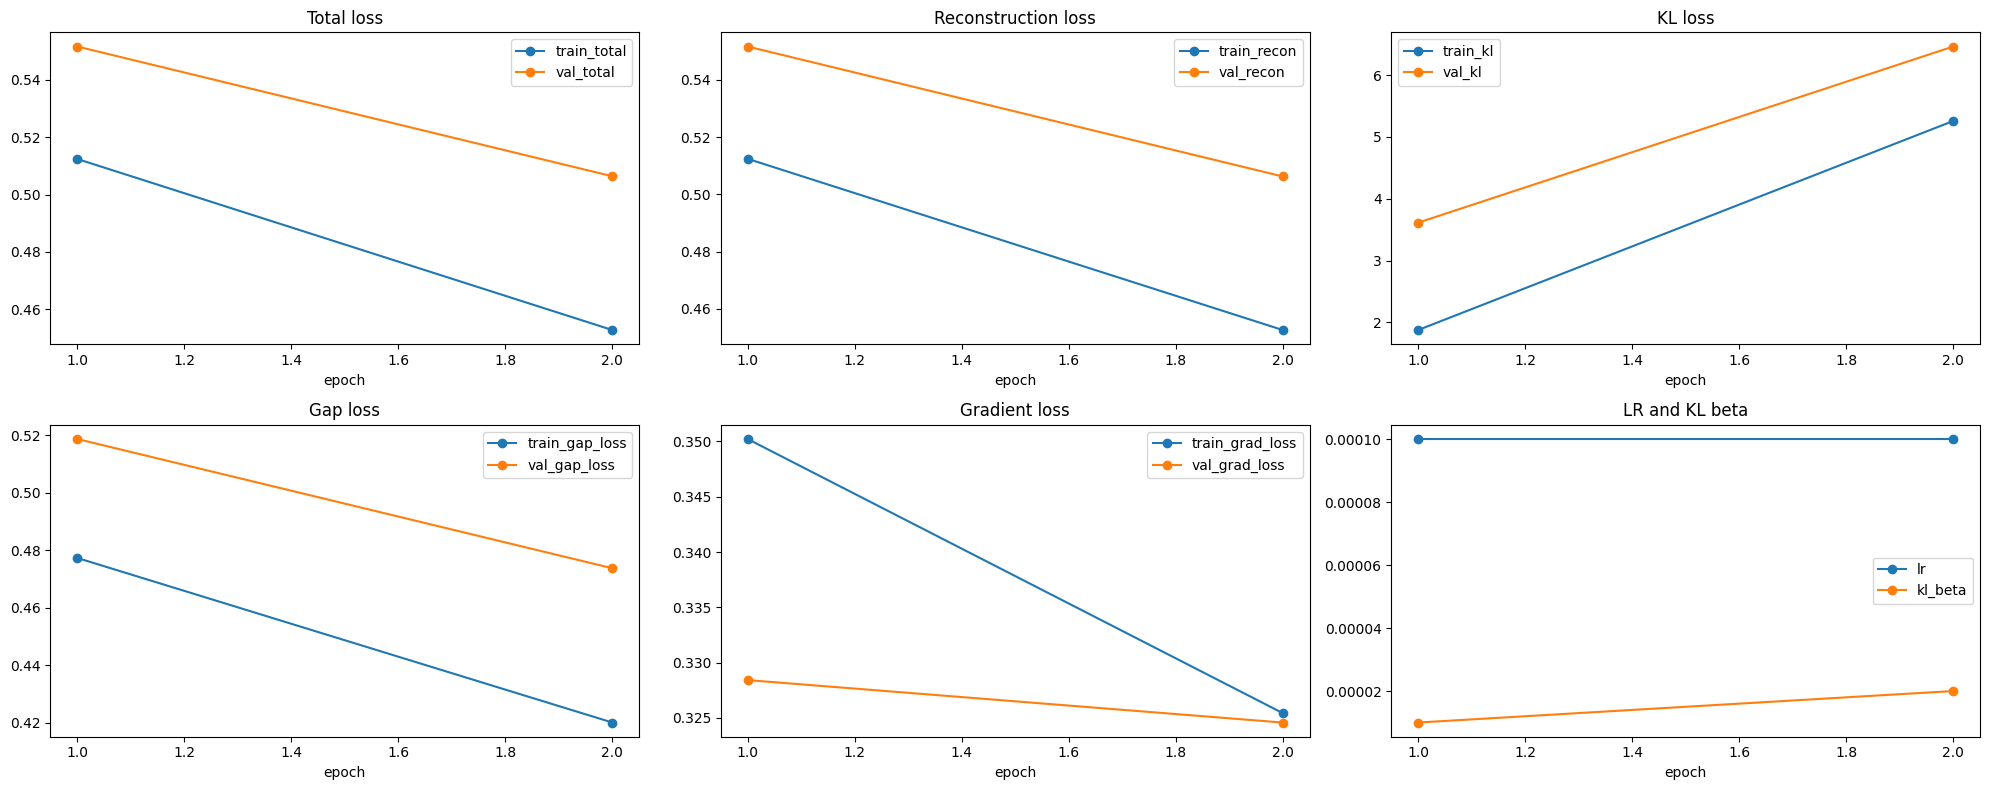

In [42]:
epochs = vae_history['history']['epoch']

fig, axes = plt.subplots(2, 3, figsize=(20, 8))

axes[0, 0].plot(epochs, vae_history['history']['train_total'], marker='o', label='train_total')
axes[0, 0].plot(epochs, vae_history['history']['val_total'], marker='o', label='val_total')
axes[0, 0].set_title('Total loss')
axes[0, 0].set_xlabel('epoch')
axes[0, 0].legend()

axes[0, 1].plot(epochs, vae_history['history']['train_recon'], marker='o', label='train_recon')
axes[0, 1].plot(epochs, vae_history['history']['val_recon'], marker='o', label='val_recon')
axes[0, 1].set_title('Reconstruction loss')
axes[0, 1].set_xlabel('epoch')
axes[0, 1].legend()

axes[0, 2].plot(epochs, vae_history['history']['train_kl'], marker='o', label='train_kl')
axes[0, 2].plot(epochs, vae_history['history']['val_kl'], marker='o', label='val_kl')
axes[0, 2].set_title('KL loss')
axes[0, 2].set_xlabel('epoch')
axes[0, 2].legend()

axes[1, 0].plot(epochs, vae_history['history']['train_gap_loss'], marker='o', label='train_gap_loss')
axes[1, 0].plot(epochs, vae_history['history']['val_gap_loss'], marker='o', label='val_gap_loss')
axes[1, 0].set_title('Gap loss')
axes[1, 0].set_xlabel('epoch')
axes[1, 0].legend()

axes[1, 1].plot(epochs, vae_history['history']['train_grad_loss'], marker='o', label='train_grad_loss')
axes[1, 1].plot(epochs, vae_history['history']['val_grad_loss'], marker='o', label='val_grad_loss')
axes[1, 1].set_title('Gradient loss')
axes[1, 1].set_xlabel('epoch')
axes[1, 1].legend()

axes[1, 2].plot(epochs, vae_history['history']['lr'], marker='o', label='lr')
axes[1, 2].plot(epochs, vae_history['history']['kl_beta'], marker='o', label='kl_beta')
axes[1, 2].set_title('LR and KL beta')
axes[1, 2].set_xlabel('epoch')
axes[1, 2].legend()

plt.tight_layout()
plt.show()


## Step 9: VAE Inspection

This visualizes the masked input, clean target, and reconstructed gap for a few validation examples. The reconstruction is inserted back into the masked spectrogram so you can inspect the actual inpainting result.

In [43]:
@torch.no_grad()
def inspect_vae(
    vae: ContextVAE,
    ctx_encoder: nn.Module,
    dataloader,
    device: torch.device,
    n_examples: int = 3,
) -> None:
    vae.eval()
    ctx_encoder.eval()

    batch = next(iter(dataloader))
    x = batch['x'][:n_examples].to(device)
    y = batch['y'][:n_examples].to(device)
    mask = batch['mask'][:n_examples].to(device)

    c_left, c_right = encode_context(ctx_encoder, x, mask)
    x_gap_target, gap_valid_mask = extract_gap(y, mask)
    mu, log_var = vae.encode(x_gap_target, c_left, c_right)
    z = vae.reparameterise(mu, log_var)
    recon_gap = vae.decode(z, c_left, c_right, target_shape=x_gap_target.shape[-2:])

    bounds = find_gap_bounds_per_sample(mask)
    merged = x.clone()
    for b, (gs, ge) in enumerate(bounds):
        w = ge - gs
        merged[b:b+1, :, :, gs:ge] = recon_gap[b:b+1, :, :, :w]

    print('inspect_vae debug')
    print(f'  x shape:           {tuple(x.shape)}')
    print(f'  target gap shape:  {tuple(x_gap_target.shape)}')
    print(f'  mu/log_var shape:  {tuple(mu.shape)} / {tuple(log_var.shape)}')
    print(f'  recon_gap shape:   {tuple(recon_gap.shape)}')
    print(f'  gap bounds:        {bounds}')

    x_np = x.cpu().numpy()
    y_np = y.cpu().numpy()
    recon_gap_np = recon_gap.cpu().numpy()
    merged_np = merged.cpu().numpy()

    plt.figure(figsize=(16, 4 * n_examples))
    for i in range(min(n_examples, x_np.shape[0])):
        w_i = bounds[i][1] - bounds[i][0]
        sample_loss = F.l1_loss(
            recon_gap[i:i+1, :, :, :w_i], x_gap_target[i:i+1, :, :, :w_i]
        ).item()

        plt.subplot(n_examples, 4, 4 * i + 1)
        plt.imshow(x_np[i, 0], aspect='auto', origin='lower')
        plt.title(f'Masked input {i}')
        plt.colorbar()

        plt.subplot(n_examples, 4, 4 * i + 2)
        plt.imshow(y_np[i, 0], aspect='auto', origin='lower')
        plt.title(f'Ground truth {i}')
        plt.colorbar()

        plt.subplot(n_examples, 4, 4 * i + 3)
        plt.imshow(recon_gap_np[i, 0], aspect='auto', origin='lower')
        plt.title(f'Gap recon {i} | L1={sample_loss:.4f}')
        plt.colorbar()

        plt.subplot(n_examples, 4, 4 * i + 4)
        plt.imshow(merged_np[i, 0], aspect='auto', origin='lower')
        plt.title(f'Final merged {i}')
        plt.colorbar()

    plt.tight_layout()
    plt.show()


Looking for checkpoint: C:\Local\LSE studies\st456-project-wt2026-transformers\artifacts\context_diffusion\checkpoints\vae\best_model.pt
Exists: True
Loaded best checkpoint from epoch 2 with best_score=0.506232
inspect_vae debug
  x shape:           (2, 1, 128, 1876)
  target gap shape:  (2, 1, 128, 203)
  mu/log_var shape:  (2, 4, 16, 25) / (2, 4, 16, 25)
  recon_gap shape:   (2, 1, 128, 203)
  gap bounds:        [(830, 1033), (1214, 1380)]


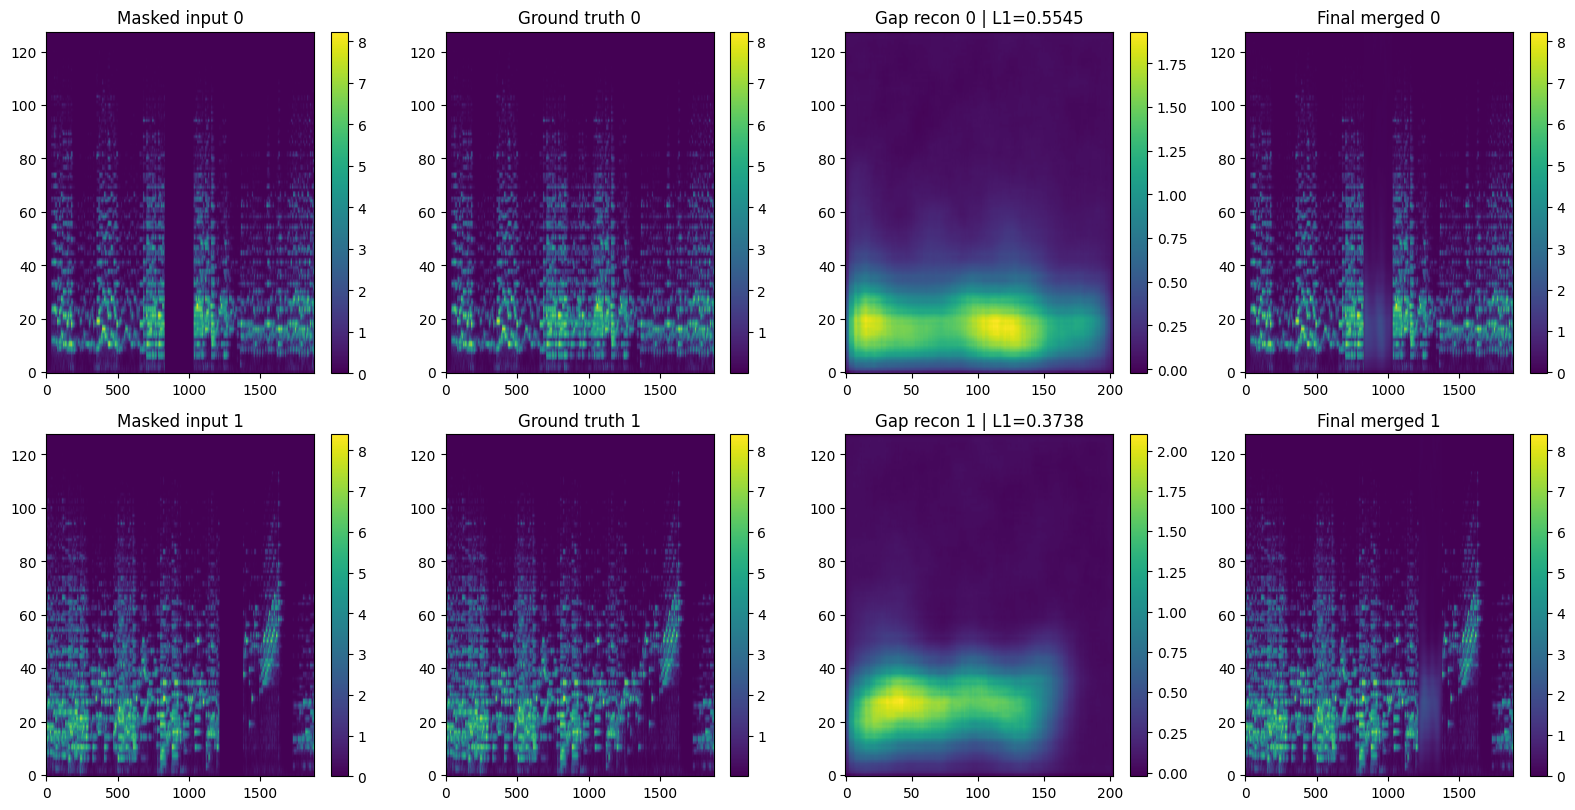

In [44]:
best_vae_model = vae_checkpoint_dir / 'best_model.pt'
print(f'Looking for checkpoint: {best_vae_model}')
print(f'Exists: {best_vae_model.exists()}')

checkpoint = torch.load(best_vae_model, map_location=device)
ctx_encoder.load_state_dict(checkpoint['ctx_encoder_state_dict'])
vae.load_state_dict(checkpoint['vae_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} with best_score={checkpoint['best_score']:.6f}")

inspect_vae(vae, ctx_encoder, val_loader, device=device, n_examples=3)
